# Heuristic annealing schedule

$\newcommand{\ket}[1]{\left|#1\right\rangle} \newcommand{\bra}[1]{\left\langle #1\right|} \newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle} \newcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}
$This notebook shows how to obtain a heuristic schedule for the annealing of the SK model, tighter than the worst-case [Wocjan and Abeyesinghe](https://arxiv.org/pdf/0804.4259) bound. 

We start by analyzing the energy variance of our instances, and determine a fitted lay for:

$$V(n,\beta) := \mathbb{E}_{H_n \sim SK}\left[\operatorname{Var}_{\pi_\beta}(H_n) \right],
\qquad 
\pi_\beta(x) \propto e^{-\beta H_n(x)}.$$

i.e. the average enegy variance of $n$-spin SK Ising hamiltonian at some inverse temperature $\beta$. Once we obtain a smooth empirical rule $V(n,\beta)$ we can determine a sule for the local spacing $\Delta \beta(n, \beta)$ and from this the annealing schedule for all instances. Importantly, the number of annealing points will grow as $\sqrt{n}$ in the high-temperature regime, and very slowly in the low-temperature regime, in streaking constrast with the $n$ worst case bound. 

In [3]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

## Estimation of the energy variance $V(n, \beta)$

The code and data for this section are present in the `estimation_variance` folder. First, we create $100$ instances of the SK model for $n = 5, ..., 30$ using the Python script `generate_files.py` and place the instances in textual format in the `estimation_variance/ising_input` folder. Only a subset of them is actually used. The C++ executable `estimation_variance_new.cpp` reads one input instance and computes the energy for all $\beta$ in a fixed predetermined grid
$$ \beta \in [...]$$
The variance of the energy is computed exactly for each instance. Results are placed in the `estimation_variance/variance_outputs` folder, with each instance in a different txt file containing pairs $(\beta, \text{var})$. The Python script `collect_var_energies.py` inspects the output folder and fills a pandas table with columns

```text
n, beta, instance, var_energy
```

Missing files, unreadable files, and missing beta values are represented as `np.nan`. 

Here we use the load the pandas file directly and filter out the missing values. 

In [17]:
# Load the long-form table created by the retrieval script.
numerical_var_energies = pd.read_pickle("../estimation_variance/var_energies.pkl")
df = numerical_var_energies.copy()
df = df[np.isfinite(df["var_energy"]) & (df["var_energy"] > 0)]

We keep in `df` the full table, but also it is convenient to have aggregated the values by $(n, \beta)$ as in here:

In [19]:
agg = df.groupby(["n", "beta"], as_index=False)\
    .agg(V=("var_energy", "mean"), V_std=("var_energy", "std"), count=("var_energy", "count"))

### Plot of the energy-variance density 

The first diagnostic is whether the variance is extensive:

$$
V(n,\beta)\approx n\,v(\beta).
$$

If this is true, the curves $V(n,\beta)/n$ should approximately collapse across $n$. It seems to be the case:

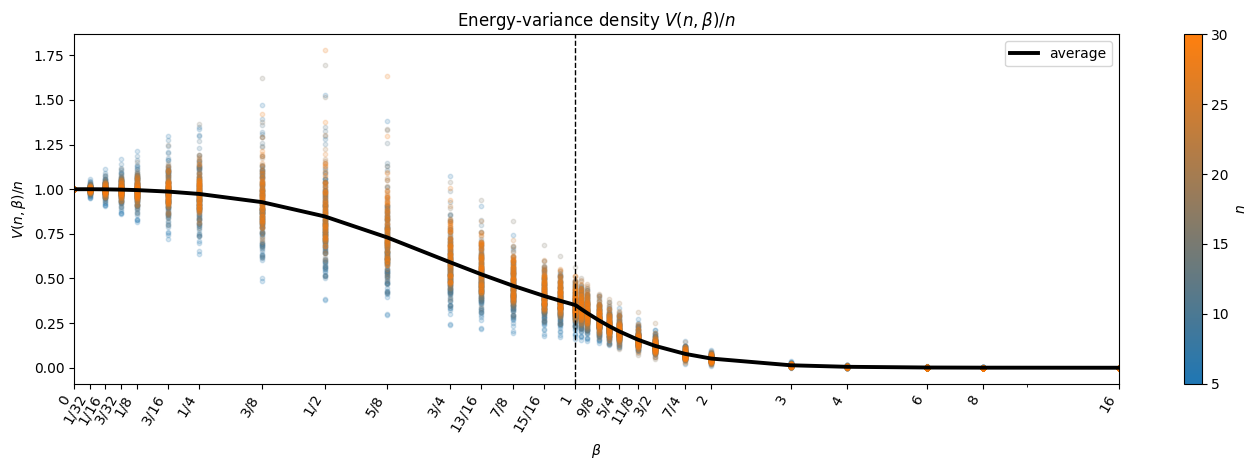

In [35]:
import matplotlib as mpl

beta_ticks = [0.0, 1.0 / 32.0, 1.0 / 16.0, 3.0 / 32.0, 1.0 / 8.0, 3.0 / 16.0, 1.0 / 4.0, 3.0 / 8.0, 1.0 / 2.0, 5.0 / 8.0, 3.0 / 4.0, 13.0 / 16.0, 7.0 / 8.0, 15.0 / 16.0, 1.0, 9.0 / 8.0, 5.0 / 4.0, 11.0 / 8.0, 3.0 / 2.0, 7.0 / 4.0, 2.0, 3.0, 4.0, 6.0, 8.0, 16.0]
beta_tick_labels = [r"$0$", r"$1/32$", r"$1/16$", r"$3/32$", r"$1/8$", r"$3/16$", r"$1/4$", r"$3/8$", r"$1/2$", r"$5/8$", r"$3/4$", r"$13/16$", r"$7/8$", r"$15/16$", r"$1$", r"$9/8$", r"$5/4$", r"$11/8$", r"$3/2$", r"$7/4$", r"$2$", r"$3$", r"$4$", r"$6$", r"$8$", r"$16$"]

df["V_over_n"] = df["var_energy"] / df["n"]

cmap = mpl.colors.LinearSegmentedColormap.from_list("blue_to_orange", ["tab:blue", "tab:orange"])
norm = mpl.colors.Normalize(vmin=df["n"].min(), vmax=df["n"].max())

plt.figure(figsize=(14, 4.8))

for n, g in df.groupby("n"):
    plt.scatter(g["beta"], g["V_over_n"], s=10, alpha=0.18, color=cmap(norm(n)))

mean_by_beta = df.groupby("beta", as_index=False)["V_over_n"].mean()
plt.plot(mean_by_beta["beta"], mean_by_beta["V_over_n"], color="black", linewidth=2.8, label="average")

plt.xscale("symlog", linthresh=1.0)
plt.xlim((0, 16))
plt.xticks(beta_ticks, beta_tick_labels, rotation=60, ha="right")
plt.axvline(1.0, color="black", linestyle="--", linewidth=1)
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.title(r"Energy-variance density $V(n,\beta)/n$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label=r"$n$")

plt.legend()
plt.tight_layout()
plt.show()

### Ansatz for the energy-variance density

We fit the energy variance through the extensive form $V(n,\beta)=n\,v(\beta)$, where $v(\beta)$ is the variance density. This is motivated by the empirical collapse of $V(n,\beta)/n$ across system sizes and by the expectation that the thermal energy fluctuations of the SK model are extensive. 

The inverse-temperature dependence is modeled with two regimes: 
* a smooth high-temperature branch for $\beta<1$, where the variance density decreases from its $\beta=0$ value to its value near the SK transition, and
* a low-temperature branch for $\beta\geq1$, where the Gibbs distribution progressively concentrates on low-energy configurations and the variance density decays as a shifted power law.

We start from a generic ansatz:
$$
v(\beta)=
\begin{cases}
v_0\exp\left[\log\left(\dfrac{v_1}{v_0}\right)\beta+\kappa\beta(1-\beta)\right], & \beta<1,\\[2mm]
v_1\left(1+\dfrac{\beta-1}{\tau}\right)^{-q}, & \beta\geq1.
\end{cases}
$$
where:
- $v_0$ is the variance density at $\beta=0$, i.e. $v(0)$. In our normalization it is close to $1$, consistently with $V(n,0)=\sum_i h_i^2+\sum_{i<j}J_{ij}^2$.
- $v_1$ is the variance density at the transition point $\beta=1$. The ansatz is continuous because both branches give $v(1)=v_1$.
- $\log(v_1/v_0)\beta$ is the minimal log-linear interpolation between $v_0$ and $v_1$ on the high-temperature interval.
- $\kappa\beta(1-\beta)$ adds curvature in the high-temperature branch while preserving the endpoints at $\beta=0$ and $\beta=1$.
- $\tau$ is the crossover scale after $\beta=1$; it controls how quickly the low-temperature decay starts.
- $q$ is the low-temperature decay exponent of the variance density. Since the annealing density scales as $\sqrt{V(n,\beta)}$, this corresponds to a low-temperature annealing-density decay exponent $q/2$.

In [66]:
def log_rmse(y, yhat):
    return np.sqrt(np.mean((np.log(yhat) - np.log(y)) ** 2))


def fit_data(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()
    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))
    return n, beta, y


def v_ansatz(theta, beta):
    log_v0, log_v1, kappa, log_tau, q = theta
    v0 = np.exp(log_v0)
    v1 = np.exp(log_v1)
    tau = np.exp(log_tau)
    beta = np.asarray(beta, dtype=float)
    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0
    v[mask] = v0 * np.exp(np.log(v1 / v0) * beta[mask] + kappa * beta[mask] * (1.0 - beta[mask]))
    v[~mask] = v1 * (1.0 + (beta[~mask] - 1.0) / tau) ** (-q)
    return v


def V_ansatz(theta, n, beta):
    return np.asarray(n, dtype=float) * v_ansatz(theta, beta)


def fit_ansatz(agg):
    n, beta, y = fit_data(agg)

    def residual(theta):
        return np.log(V_ansatz(theta, n, beta)) - y

    theta0 = [np.log(1.0), np.log(0.36), 1.25, np.log(1.3), 3.5]
    res = least_squares(residual, theta0)
    return res.x, res.cost


theta, cost = fit_ansatz(agg)
pred = V_ansatz(theta, agg["n"].to_numpy(), agg["beta"].to_numpy())

log_v0, log_v1, kappa, log_tau, q = theta

print("cost =", cost)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred))
print("v0 =", np.exp(log_v0))
print("v1 =", np.exp(log_v1))
print("kappa =", kappa)
print("tau =", np.exp(log_tau))
print("q =", q)

cost = 8.284598533736144
log-RMSE = 0.14574827732399856
v0 = 0.9907757753581404
v1 = 0.3637272909106483
kappa = 1.2731310431562697
tau = 1.3042475872846648
q = 3.520963660325346


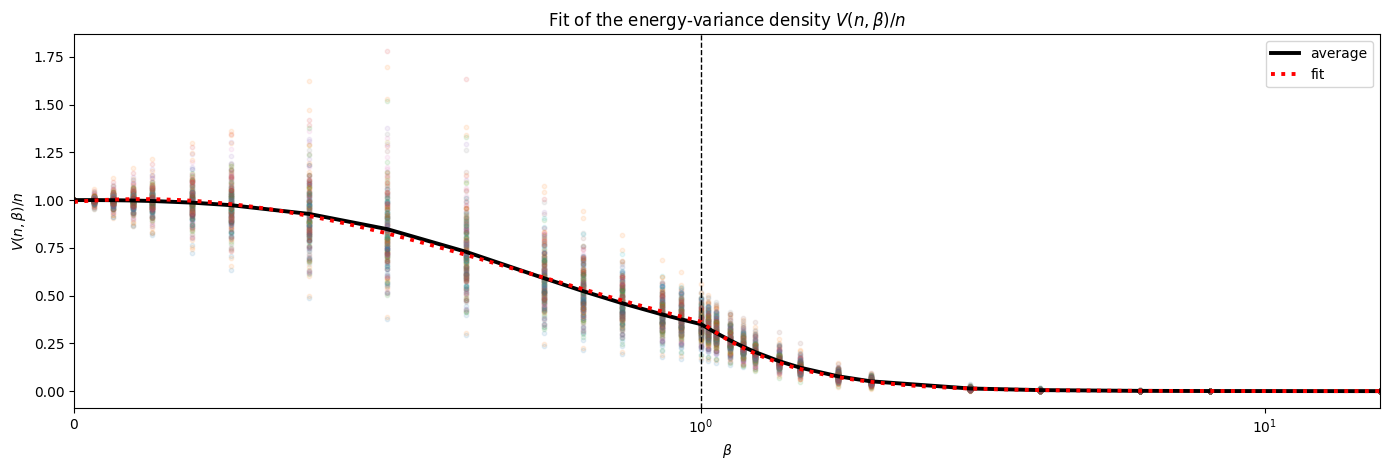

In [68]:
beta_plot = np.linspace(0.0, 16.0, 2000)
n_ref = 30
V_plot = V_ansatz(theta, np.full_like(beta_plot, n_ref), beta_plot)

mean_by_beta = df.groupby("beta", as_index=False)["V_over_n"].mean()

plt.figure(figsize=(14, 4.8))

for n, g in df.groupby("n"):
    plt.scatter(g["beta"], g["var_energy"] / g["n"], s=10, alpha=0.1)

plt.plot(mean_by_beta["beta"], mean_by_beta["V_over_n"], color="black", linewidth=2.8, label="average")
plt.plot(beta_plot, V_plot / n_ref, color="red", linewidth=2.8, linestyle=":", label="fit")

plt.axvline(1.0, color="black", linestyle="--", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlim((0, 16))
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.title(r"Fit of the energy-variance density $V(n,\beta)/n$")
plt.legend()
plt.tight_layout()
plt.show()

The ansatz can be clearly simplified by setting $v_0 = 1$ (expected variance density $1$ at $\beta = 0$), while the low-temperature decay exponent can be fixed to $q = 7/2$. In this case we obtain:
$$
v(\beta)=
\begin{cases}
\exp\left[\log(v_1)\beta+\kappa\beta(1-\beta)\right], & \beta<1,\\[2mm]
v_1\left(1+\dfrac{\beta-1}{\tau}\right)^{-7/2}, & \beta\geq1.
\end{cases}
$$

In [69]:
def v_ansatz_reduced(theta, beta):
    log_v1, kappa, log_tau = theta
    v1 = np.exp(log_v1)
    tau = np.exp(log_tau)
    beta = np.asarray(beta, dtype=float)
    v = np.empty_like(beta, dtype=float)
    mask = beta < 1.0
    v[mask] = np.exp(log_v1 * beta[mask] + kappa * beta[mask] * (1.0 - beta[mask]))
    v[~mask] = v1 * (1.0 + (beta[~mask] - 1.0) / tau) ** (-3.5)
    return v


def V_ansatz_reduced(theta, n, beta):
    return np.asarray(n, dtype=float) * v_ansatz_reduced(theta, beta)


def fit_ansatz_reduced(agg):
    d = agg[(agg["V"] > 0) & np.isfinite(agg["V"])].copy()
    n = d["n"].to_numpy(dtype=float)
    beta = d["beta"].to_numpy(dtype=float)
    y = np.log(d["V"].to_numpy(dtype=float))

    def residual(theta):
        return np.log(V_ansatz_reduced(theta, n, beta)) - y

    theta0 = [np.log(0.36), 1.25, np.log(1.3)]
    res = least_squares(residual, theta0)
    return res.x, res.cost

theta_reduced, cost_reduced = fit_ansatz_reduced(agg)
pred_reduced = V_ansatz_reduced(theta_reduced, agg["n"].to_numpy(), agg["beta"].to_numpy())

log_v1, kappa, log_tau = theta_reduced

print("cost =", cost_reduced)
print("log-RMSE =", log_rmse(agg["V"].to_numpy(), pred_reduced))
print("v0 =", 1.0)
print("v1 =", np.exp(log_v1))
print("kappa =", kappa)
print("tau =", np.exp(log_tau))
print("q =", 3.5)

cost = 8.29256326549385
log-RMSE = 0.14581832097523104
v0 = 1.0
v1 = 0.36509390795294755
kappa = 1.235355174281897
tau = 1.2864586095390813
q = 3.5


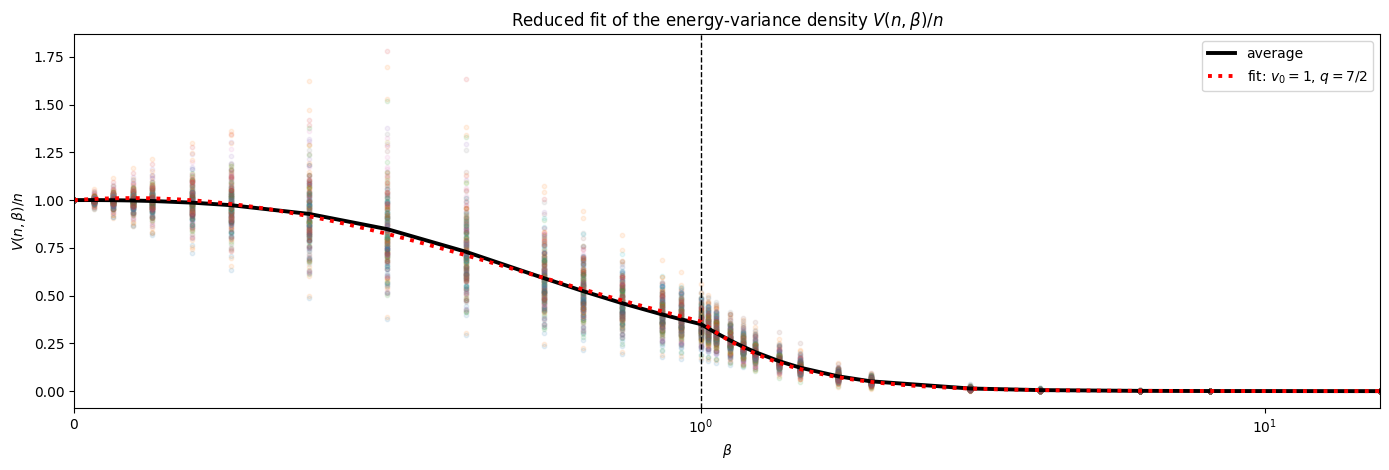

In [70]:
beta_plot = np.linspace(0.0, 16.0, 2000)
n_ref = 30
V_plot = V_ansatz_reduced(theta_reduced, np.full_like(beta_plot, n_ref), beta_plot)

mean_by_beta = df.groupby("beta", as_index=False)["V_over_n"].mean()

plt.figure(figsize=(14, 4.8))

for n, g in df.groupby("n"):
    plt.scatter(g["beta"], g["var_energy"] / g["n"], s=10, alpha=0.1)

plt.plot(mean_by_beta["beta"], mean_by_beta["V_over_n"], color="black", linewidth=2.8, label="average")
plt.plot(beta_plot, V_plot / n_ref, color="red", linewidth=2.8, linestyle=":", label=r"fit: $v_0=1$, $q=7/2$")

plt.axvline(1.0, color="black", linestyle="--", linewidth=1)
plt.xscale("symlog", linthresh=1.0)
plt.xlim((0, 16))
plt.xlabel(r"$\beta$")
plt.ylabel(r"$V(n,\beta)/n$")
plt.title(r"Reduced fit of the energy-variance density $V(n,\beta)/n$")
plt.legend()
plt.tight_layout()
plt.show()

#### How to catch the outliers

To make the fitted ansatz conservative, we compare each empirical variance density against the fitted one:
$$
\frac{V_{n}(\beta)/n}{v_{\mathrm{fit}}(\beta)}.
$$

In the observed data, this ratio is bounded by  $4$ for $\beta<1$ and by (less than) $16$ for $\beta\geq1$. Therefore, a safe variance-density envelope can be obtained by multiplying the fitted ansatz by $4$ in the high-temperature region and by $16$ in the low-temperature region.

In [71]:
tmp = df.copy()
tmp["V_fit_over_n"] = v_ansatz_reduced(theta_reduced, tmp["beta"].to_numpy())
tmp["ratio"] = tmp["V_over_n"] / tmp["V_fit_over_n"]

print("max ratio beta < 1:", tmp.loc[tmp["beta"] < 1.0, "ratio"].max())
print("max ratio beta > 1:", tmp.loc[tmp["beta"] > 1.0, "ratio"].max())

max ratio beta < 1: 2.2953567542108044
max ratio beta > 1: 13.685093887171641


#### Fitted law for $\Delta \beta$

We have that 

$$
v(\beta) \le
\begin{cases}
4 \exp\left[\log(v_1)\beta+\kappa\beta(1-\beta)\right], & \beta<1,\\[2mm]
16 v_1\left(1+\dfrac{\beta-1}{\tau}\right)^{-7/2}, & \beta\geq1.
\end{cases}, \qquad v_1 \approx 0.365, \kappa \approx 1.23, \tau\approx 1.286
$$

Equivalently,

$$
v(\beta) \le
\begin{cases}
4\exp\left(0.222\,\beta - 1.23\,\beta^2\right), & \beta<1,\\[2mm]
14.085\,(\beta+0.286)^{-7/2}, & \beta\geq1.
\end{cases}
$$

Therefore, using the conservative upper envelope for $v(\beta)$, we choose

$$
\Delta\beta(n, \beta) = \frac{2}{\sqrt{n v(\beta)}} = \frac{1}{\sqrt{n}}
\begin{cases}
\exp\left(-0.111\,\beta + 0.615\,\beta^2\right), & \beta<1,\\[3mm]
0.533\,(\beta+0.286)^{7/4}, & \beta\geq1.
\end{cases}
$$

## Derivation of the local annealing points density

Let the overlap between Gibbs states be

$$\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}} = \frac{Z(\beta+\Delta\beta/2)}{\sqrt{Z(\beta)Z(\beta+\Delta\beta)}}.$$

By the assumption on the overlap, we require $|\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}}|^2 \ge 1/e$, or equivalently $|\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}}| \ge e^{-1/2} = \gamma$. Let $F(\beta) := \log Z(\beta)$. Then

$$\log \braket{\pi_\beta}{\pi_{\beta+\Delta\beta}} = F(\beta+\Delta\beta/2) - \frac{F(\beta)+F(\beta+\Delta\beta)}{2} \approx - \frac{(\Delta \beta)^2}{8} F''(\beta) + \mathcal{O}((\Delta \beta)^3)$$

where the approximation comes from the Taylor expansion around $\beta$. Substituting $\log \braket{\pi_\beta}{\pi_{\beta+\Delta\beta}} = \log \gamma = -1/2$ and $F''(\beta)$ with $V(n, \beta)$, we obtain

$$\Delta \beta(n, \beta) = \frac{2}{\sqrt{V(n, \beta)}}.$$

To determine the schedule, a simple greedy rule is the following:
1. start at $\beta_0 = 0$,
2. find the next step via $\beta_{k+1} = \beta_k + \Delta\beta(n, \beta_k)$ until $\beta_F$ has been reached. 

In [74]:
def delta_beta(n, beta):
    beta = np.asarray(beta, dtype=float)
    return np.where(beta < 1.0, np.exp(-0.111 * beta + 0.615 * beta**2), 0.533 * (beta + 0.286)**1.75) / np.sqrt(n)

def tight_schedule_annealing(n: int, beta: float) -> list[float]:
    schedule = [0.0]
    while schedule[-1] < beta:
        next_beta = schedule[-1] + float(delta_beta(n, schedule[-1]))
        schedule.append(min(next_beta, beta))
    return schedule